# BME 574 — Project 3 explained
### Three things the lecture did not cover, and the project is graded on

The lecture gave you the network: layers, ReLU, cross-entropy, backpropagation, and the
train/test split as an idea. This notebook is about what happens when you point that machinery at
a **real biomedical dataset**, where three things go wrong that never go wrong on a toy problem.

1. **Your test set is not what you think it is.** Splitting rows at random lets the same patient
   appear on both sides, and the score you report is then partly a measure of how well the model
   recognises *people*.
2. **Accuracy is the least informative number you have.** On a dataset where 93% of records are
   normal, a model that has learned nothing scores 0.93.
3. **One training run is not evidence.** Initialisation and batch order are random. On some
   datasets that moves the accuracy by more than the difference you are trying to measure.

Read this top to bottom and run every cell — about 30 minutes. There is nothing to hand in. It runs
on `demo.npz`, the small synthetic stand-in, so it finishes in under a minute.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})
np.set_printoptions(precision=3, suppress=True)
torch.manual_seed(0)
print('torch', torch.__version__)

torch 2.14.0+cu130


---
## 0 · What is in a bundle

Every track arrives as one `.npz` file with the same nine arrays. Unpacking it is the same three
lines whichever track you get, which is the point — your code should not care which dataset it is
looking at.

| key | shape | what it is |
|---|---|---|
| `X` | `(n, p)` float32 | the feature matrix, **unscaled** — scaling is your job, and it is a modelling decision |
| `y` | `(n,)` int64 | the class label, already coded `0 … K-1` |
| `subject` | `(n,)` int64 | which person (or recording) each row came from |
| `train_idx`, `test_idx` | int64 | the official split — **use it, do not make your own** |
| `feature_names`, `class_names` | str | for your figures and your memo |
| `track`, `split_kind`, `source`, `notes` | str | provenance; `notes` is worth reading |

In [2]:
def load_bundle(path):
    z = np.load(path, allow_pickle=True)
    b = {k: z[k] for k in z.files}
    for k in ('track', 'split_kind', 'source', 'notes'):
        b[k] = str(b[k])
    b['feature_names'] = [str(s) for s in b['feature_names']]
    b['class_names'] = [str(s) for s in b['class_names']]
    return b


B = load_bundle('bundles_p3/demo.npz')
X, y, subject = B['X'], B['y'], B['subject']
train_idx, test_idx = B['train_idx'], B['test_idx']
CLASSES = B['class_names']
K = len(CLASSES)

print('track   :', B['track'])
print('X       :', X.shape, X.dtype)
print('classes :', CLASSES)
print('subjects:', len(np.unique(subject)), ' rows per subject: %.1f'
      % (len(y) / len(np.unique(subject))))
print('split   :', B['split_kind'], '->', len(train_idx), 'train /', len(test_idx), 'test')
print()
print(B['notes'])

track   : demo
X       : (985, 24) float32
classes : ['class A', 'class B', 'class C']
subjects: 60  rows per subject: 16.4
split   : subject-wise split -> 734 train / 251 test

Synthetic stand-in with the same shape as a real track: a curved class boundary the straight-boundary model cannot follow, a per-subject nuisance offset (so a random row split leaks), and one rare class. Use it to check that your code runs before your real bundle arrives. Do not report results from it.


---
# 1 · Your test set is not what you think it is

Here is the whole problem in one picture. Each of the 60 subjects in this bundle contributes about
16 rows. Two of those rows, from the same subject, are not two independent observations — they share
that person's sensor placement, skin impedance, posture, baseline drift, everything.

Split the **rows** at random and you put some of subject 17's rows in training and the rest in test.
The model does not have to learn what the condition looks like. It can learn what *subject 17*
looks like, and then answer from memory.

Let's measure exactly how much of the test set that contaminates.

In [3]:
# the honest split, as shipped in the bundle: whole subjects held out
shared_subject = np.intersect1d(subject[train_idx], subject[test_idx])

# the tempting alternative: shuffle rows, take 25% for test
rtr, rte = train_test_split(np.arange(len(y)), test_size=len(test_idx) / len(y),
                            random_state=0, stratify=y)
shared_row = np.intersect1d(subject[rtr], subject[rte])

n_subj = len(np.unique(subject))
print('subject-wise split : %3d of %d subjects appear in BOTH halves' % (len(shared_subject), n_subj))
print('random row split   : %3d of %d subjects appear in BOTH halves' % (len(shared_row), n_subj))
print()
print('Under the random split, %.0f%% of the test rows come from a subject the model'
      % (100 * np.isin(subject[rte], shared_row).mean()))
print('has already seen during training.')

subject-wise split :   0 of 60 subjects appear in BOTH halves
random row split   :  58 of 60 subjects appear in BOTH halves

Under the random split, 100% of the test rows come from a subject the model
has already seen during training.


### Why this is not a small effect

It is tempting to think "so what, it sees a few of the same people — the features are still the
features." But the leak is not a rounding error, because subject identity is often *easier* to learn
than the condition. Gradient descent takes the easy route every time.

Below: the same architecture, the same hyperparameters, the same data. Only the split changes.

In [4]:
def build_model(n_features, n_classes, hidden=(64, 32), p_drop=0.3, seed=0):
    torch.manual_seed(seed)
    sizes = [n_features] + list(hidden)
    layers = []
    for a, b in zip(sizes[:-1], sizes[1:]):
        layers += [nn.Linear(a, b), nn.ReLU(), nn.Dropout(p_drop)]
    layers.append(nn.Linear(sizes[-1], n_classes))
    return nn.Sequential(*layers)


def prep(tr, te):
    # the scaler is fitted on TRAINING rows only - it is a model parameter
    sc = StandardScaler().fit(X[tr])
    return (torch.tensor(sc.transform(X[tr]), dtype=torch.float32),
            torch.tensor(y[tr], dtype=torch.long),
            torch.tensor(sc.transform(X[te]), dtype=torch.float32),
            torch.tensor(y[te], dtype=torch.long))


def train_and_score(tr, te, seed=0, epochs=40, weight=None):
    Xa, ya, Xv, yv = prep(tr, te)
    model = build_model(Xa.shape[1], K, seed=seed)
    loader = DataLoader(TensorDataset(Xa, ya), batch_size=128, shuffle=True,
                        generator=torch.Generator().manual_seed(seed + 100))
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossfn = nn.CrossEntropyLoss(weight=weight)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            lossfn(model(xb), yb).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xv).argmax(1).numpy()
    return pred, yv.numpy()


p_honest, t_honest = train_and_score(train_idx, test_idx)
p_leaky, t_leaky = train_and_score(rtr, rte)

a_honest = (p_honest == t_honest).mean()
a_leaky = (p_leaky == t_leaky).mean()
print('subject-wise split (honest) : accuracy %.4f' % a_honest)
print('random row split   (leaky)  : accuracy %.4f' % a_leaky)
print('the split alone is worth     : %+.4f' % (a_leaky - a_honest))

subject-wise split (honest) : accuracy 0.8526
random row split   (leaky)  : accuracy 0.8725
the split alone is worth     : +0.0199


On this small synthetic bundle the gap is modest. On the real tracks it is not: on the human
activity data it is worth **almost four points of accuracy**, and on the EEG data every one of the
500 subjects lands on both sides of a random split. Those are numbers you will measure yourself in
Step 4 of the project.

The rule to take away:

> **Split along whatever unit you want your claim to generalise to.** If you want to say "this model
> detects seizures in patients it has never seen", then patients — not rows — are what the test set
> must hold out.

This is not a neural-network problem. It applies identically to the linear baseline, to random
forests, to anything. It is a *study design* problem that happens to bite hardest when the model is
flexible enough to exploit it.

### The same mistake wearing a different hat: the scaler

`StandardScaler().fit(X)` on the *whole* matrix subtracts a mean computed partly from your test
rows. That mean is a number your model uses at prediction time, so it is a model parameter, and
fitting it on test data is leakage — smaller than the split leak, but the same category of error.
Fit it on `X[train_idx]` and apply it to both halves. The `prep()` function above does exactly that.

In [5]:
sc_right = StandardScaler().fit(X[train_idx])
sc_wrong = StandardScaler().fit(X)                      # <- leaks
print('feature 0 mean, fitted on train only : %+.4f' % sc_right.mean_[0])
print('feature 0 mean, fitted on everything : %+.4f' % sc_wrong.mean_[0])
print()
print('After the RIGHT scaler, the TEST rows do not have mean zero, and that is correct:')
print('   train mean %+.6f     test mean %+.6f'
      % (sc_right.transform(X[train_idx])[:, 0].mean(),
         sc_right.transform(X[test_idx])[:, 0].mean()))

feature 0 mean, fitted on train only : -0.1351
feature 0 mean, fitted on everything : -0.1451

After the RIGHT scaler, the TEST rows do not have mean zero, and that is correct:
   train mean -0.000000     test mean -0.020831


---
# 2 · Accuracy is the least informative number you have

One of your three possible tracks is a thyroid screening dataset in which **92.6% of records are
normal**. Consider a model consisting of the single line `return "normal"`.

Its accuracy is 0.926. It has never seen a feature. It would miss every case of thyroid disease in
the dataset. This is the number a careless report would lead with.

You need three more things.

In [6]:
# an extreme but instructive imbalance, built to make the point
rng = np.random.default_rng(0)
truth = np.array([0] * 926 + [1] * 51 + [2] * 23)
rng.shuffle(truth)
lazy = np.zeros_like(truth)                       # the "always normal" model

print('accuracy of a model that always says class 0 : %.4f' % (lazy == truth).mean())
print('macro-F1 of the same model                   : %.4f'
      % f1_score(truth, lazy, average='macro'))
print()
for c in range(3):
    print('   recall, class %d : %.3f' % (c, recall_score(truth, lazy, labels=[c],
                                                          average='macro')))

accuracy of a model that always says class 0 : 0.9260
macro-F1 of the same model                   : 0.3205

   recall, class 0 : 1.000
   recall, class 1 : 0.000
   recall, class 2 : 0.000


### The three numbers that do tell you something

**Per-class recall.** Of all the records that truly are class *c*, what fraction did the model find?
This is the number a clinician cares about, because a missed case and a false alarm are not the same
event and do not have the same cost. A screening test with 0.00 recall on the disease class is not
a screening test.

**Macro-F1.** The mean of the per-class F1 scores, each class counted **once regardless of how many
rows it has**. That is the whole trick: a rare class contributes as much to macro-F1 as the majority
class, so ignoring it is expensive. Note above that accuracy 0.926 comes with macro-F1 0.32.

**The confusion matrix.** Rows are truth, columns are prediction. Accuracy is one number squeezed
out of this whole table; the table tells you *which* mistakes, and mistakes are not interchangeable.
Confusing two kinds of walking is a different problem from confusing seizure with baseline.

In [7]:
p_dem, t_dem = train_and_score(train_idx, test_idx)
cm = confusion_matrix(t_dem, p_dem, labels=list(range(K)))
cmn = cm / cm.sum(1, keepdims=True)

print('confusion matrix, rows = truth, columns = prediction')
print('%-10s' % '' + ''.join('%12s' % c[:11] for c in CLASSES))
for i in range(K):
    print('%-10s' % CLASSES[i][:10] + ''.join('%12d' % v for v in cm[i]))
print()
print('row-normalised, so the diagonal IS the per-class recall')
print('%-10s' % '' + ''.join('%12s' % c[:11] for c in CLASSES))
for i in range(K):
    print('%-10s' % CLASSES[i][:10] + ''.join('%12.3f' % v for v in cmn[i]))
print()
print('accuracy %.4f    macro-F1 %.4f' % ((p_dem == t_dem).mean(),
                                          f1_score(t_dem, p_dem, average='macro')))

confusion matrix, rows = truth, columns = prediction
               class A     class B     class C
class A            100          14           0
class B              7          89           8
class C              0           8          25

row-normalised, so the diagonal IS the per-class recall
               class A     class B     class C
class A          0.877       0.123       0.000
class B          0.067       0.856       0.077
class C          0.000       0.242       0.758

accuracy 0.8526    macro-F1 0.8302


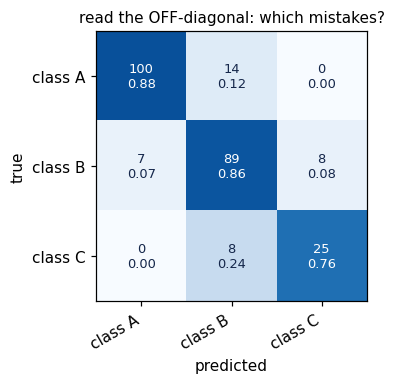

In [8]:
fig, ax = plt.subplots(figsize=(4.4, 3.6))
ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(K)); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_yticks(range(K)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
for i in range(K):
    for j in range(K):
        ax.text(j, i, '%d\n%.2f' % (cm[i, j], cmn[i, j]), ha='center', va='center',
                fontsize=8.5, color='white' if cmn[i, j] > 0.55 else '#14264A')
ax.set_title('read the OFF-diagonal: which mistakes?', fontsize=10)
plt.tight_layout(); plt.show()

### Tilting the model toward the rare class

`nn.CrossEntropyLoss` takes a `weight` argument: one number per class, multiplying that class's
contribution to the loss. Make mistakes on the rare class cost more and gradient descent will spend
more capacity on them.

The conventional choice is **inverse frequency**, `n_total / (K · n_c)`, computed on the
**training** labels — using the test labels to set your weights is, again, leakage.

What you should expect is **not a free win.**

In [9]:
ytr_np = y[train_idx]
n_c = np.bincount(ytr_np, minlength=K)
w = torch.tensor(len(ytr_np) / (K * n_c), dtype=torch.float32)
print('training counts', n_c, ' -> weights', w.numpy())
print()

p_w, t_w = train_and_score(train_idx, test_idx, weight=w)

print('%-16s %14s %14s' % ('class', 'recall plain', 'recall weighted'))
for c in range(K):
    print('%-16s %14.3f %14.3f'
          % (CLASSES[c],
             recall_score(t_dem, p_dem, labels=[c], average='macro'),
             recall_score(t_w, p_w, labels=[c], average='macro')))
print()
print('%-16s %14.4f %14.4f' % ('accuracy', (p_dem == t_dem).mean(), (p_w == t_w).mean()))
print('%-16s %14.4f %14.4f' % ('macro-F1',
                               f1_score(t_dem, p_dem, average='macro'),
                               f1_score(t_w, p_w, average='macro')))

training counts [303 292 139]  -> weights [0.807 0.838 1.76 ]



class              recall plain recall weighted
class A                   0.877          0.868
class B                   0.856          0.788
class C                   0.758          0.879

accuracy                 0.8526         0.8367
macro-F1                 0.8302         0.8177


Recall on the rare class goes up. Overall accuracy usually goes down, and recall on some other class
goes down with it. You have not made the model better; you have **moved it along a trade-off**,
buying sensitivity with specificity.

Whether that trade is worth making is a clinical question about the relative cost of a missed case
against a false alarm. Your loss function cannot answer it, and neither can macro-F1. Say which way
you went and why — that argument is what Question 5 of the memo is asking for.

---
# 3 · One training run is not evidence

Three things in this pipeline are random: the initial weights, the order examples are drawn in, and
which units dropout switches off on each step. Change the seed and you get a **different model** —
same architecture, same data, same hyperparameters, different numbers.

So when you report "the network got 0.947 and the linear model got 0.955", the honest question is:
is 0.008 bigger than the amount your own answer moves when you change nothing but the seed?

Train the same thing five times and look.

In [10]:
accs, f1s = [], []
for s in range(5):
    p_s, t_s = train_and_score(train_idx, test_idx, seed=s)
    accs.append((p_s == t_s).mean())
    f1s.append(f1_score(t_s, p_s, average='macro'))
    print('seed %d   accuracy %.4f   macro-F1 %.4f' % (s, accs[-1], f1s[-1]))

accs = np.array(accs)
print()
print('mean %.4f   sd %.4f   range [%.4f, %.4f]   spread %.4f'
      % (accs.mean(), accs.std(), accs.min(), accs.max(), accs.max() - accs.min()))

seed 0   accuracy 0.8526   macro-F1 0.8302


seed 1   accuracy 0.8566   macro-F1 0.8387


seed 2   accuracy 0.8924   macro-F1 0.8730


seed 3   accuracy 0.8645   macro-F1 0.8458


seed 4   accuracy 0.8765   macro-F1 0.8667

mean 0.8685   sd 0.0145   range [0.8526, 0.8924]   spread 0.0398


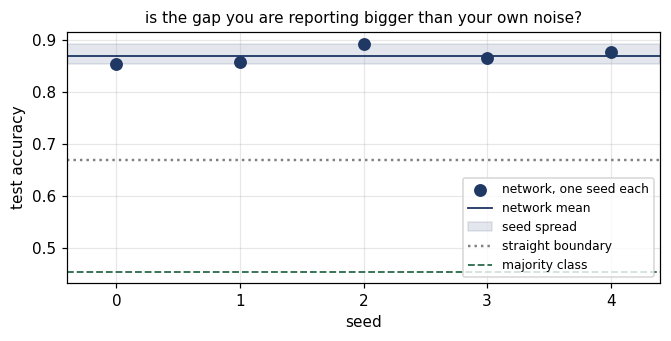

network mean minus straight boundary : +0.1992
seed-to-seed spread of the network   :  0.0398


In [11]:
Xa, ya, Xv, yv = prep(train_idx, test_idx)
lin = LogisticRegression(max_iter=3000).fit(Xa.numpy(), ya.numpy())
a_lin = (lin.predict(Xv.numpy()) == yv.numpy()).mean()

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.scatter(range(len(accs)), accs, s=55, color='#1F3864', zorder=3, label='network, one seed each')
ax.axhline(accs.mean(), color='#1F3864', lw=1.2, label='network mean')
ax.fill_between([-0.4, len(accs) - 0.6], accs.min(), accs.max(), color='#1F3864', alpha=.12,
                label='seed spread')
ax.axhline(a_lin, color='grey', ls=':', lw=1.6, label='straight boundary')
maj = (yv.numpy() == np.bincount(ya.numpy()).argmax()).mean()
ax.axhline(maj, color='#2E6B4F', ls='--', lw=1.2, label='majority class')
ax.set_xlim(-0.4, len(accs) - 0.6); ax.set_xticks(range(len(accs)))
ax.set_xlabel('seed'); ax.set_ylabel('test accuracy')
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=.3)
ax.set_title('is the gap you are reporting bigger than your own noise?', fontsize=10)
plt.tight_layout(); plt.show()

print('network mean minus straight boundary : %+.4f' % (accs.mean() - a_lin))
print('seed-to-seed spread of the network   :  %.4f' % (accs.max() - accs.min()))

### How to state the result

Three cases, three sentences:

- **Gap clearly bigger than the spread.** "Across seeds the network reached 0.967 ± 0.002
  against the straight boundary's 0.814." You may claim the win.
- **Gap comparable to the spread.** "The network reached 0.942 ± 0.005 against 0.955; the difference
  is within the seed-to-seed variation, so this experiment does not separate them." This is a
  **complete, correct answer** and it earns full marks.
- **The baseline wins by more than the spread.** Say so, plainly, and then ask why. On a dataset
  whose 561 features are already hand-engineered sums, correlations and FFT coefficients, the
  non-linear structure a network exists to find may simply have been engineered away before you got
  the file.

Three seeds is what the project asks for. It is not a lot — you cannot run a t-test on three
numbers and should not pretend otherwise — but it is enough to tell "clearly bigger" from
"indistinguishable", which is the decision you actually have to make.

> **What is *not* acceptable**: running until you get a good seed, and reporting that one.

---
# 4 · Two PyTorch conventions that silently cost you points

The lecture demo covered these, but they are the two that fail *quietly* — no exception, no
warning, just a worse number — so they are worth seeing once more.

### Your model must output logits, not probabilities

`nn.CrossEntropyLoss` applies `log_softmax` **internally**. If your last layer is a `nn.Softmax`,
you have applied softmax twice. Nothing raises. The model still trains. It just trains worse,
because the doubly-squashed outputs have much flatter gradients.

In [12]:
Xa, ya, Xv, yv = prep(train_idx, test_idx)
lossfn = nn.CrossEntropyLoss()

right = build_model(Xa.shape[1], K, seed=0)
wrong = nn.Sequential(*(list(build_model(Xa.shape[1], K, seed=0)) + [nn.Softmax(dim=1)]))

for name, m in (('logits (right)', right), ('softmax then CE (wrong)', wrong)):
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    loader = DataLoader(TensorDataset(Xa, ya), batch_size=128, shuffle=True,
                        generator=torch.Generator().manual_seed(100))
    for _ in range(40):
        m.train()
        for xb, yb in loader:
            opt.zero_grad(); lossfn(m(xb), yb).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        acc = (m(Xv).argmax(1) == yv).double().mean().item()
    print('%-26s test accuracy %.4f' % (name, acc))
print()
print('No error, no warning. Just a worse model.')

logits (right)             test accuracy 0.8526


softmax then CE (wrong)    test accuracy 0.7888

No error, no warning. Just a worse model.


### `model.train()` and `model.eval()`

Dropout is active in `train()` mode and switched off in `eval()` mode. Score a model without calling
`.eval()` and you are scoring a randomly crippled version of it — and the number changes every time
you run the cell.

In [13]:
m = build_model(Xa.shape[1], K, seed=0)
opt = torch.optim.Adam(m.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(Xa, ya), batch_size=128, shuffle=True,
                    generator=torch.Generator().manual_seed(100))
for _ in range(40):
    m.train()
    for xb, yb in loader:
        opt.zero_grad(); lossfn(m(xb), yb).backward(); opt.step()

m.eval()
with torch.no_grad():
    print('eval()  mode, scored 3 times: ', end='')
    print('  '.join('%.4f' % (m(Xv).argmax(1) == yv).double().mean() for _ in range(3)))

m.train()
with torch.no_grad():
    print('train() mode, scored 3 times: ', end='')
    print('  '.join('%.4f' % (m(Xv).argmax(1) == yv).double().mean() for _ in range(3)))
print()
print('Three identical numbers versus three different ones. That is dropout.')

eval()  mode, scored 3 times: 0.8526  0.8526  0.8526
train() mode, scored 3 times: 0.7928  0.7849  0.8287

Three identical numbers versus three different ones. That is dropout.


---
## What to carry into the project

| | The rule | Where it bites |
|---|---|---|
| **1** | Hold out whole subjects, and fit the scaler on training rows only | Step 0 and Step 4 |
| **2** | Report accuracy, macro-F1, per-class recall and the confusion matrix — all four | Step 3 |
| **3** | Three seeds before you claim anything; compare the gap to the spread | Step 4 |
| **4** | Logits out of the model, `eval()` before you score | Steps 1 and 2 |

Now open **`BME574_Project3_starter.ipynb`**. It has five cells for you to write; everything else is
done for you.